# Análisis concentración de material particulado (PM2.5)

## Introducción

Este proyecto aborda el análisis y la predicción y/o pronóstico de la concentración de partículas PM2.5 en Beijing, un problema ambiental de gran relevancia. Para ello, se utiliza un conjunto de datos multivariado y de series de tiempo proveniente del **UCI Machine Learning Repository**, específicamente el conjunto de datos "Beijing PM2.5".

El dataset incluye mediciones horarias de concentración de PM2.5 de la Embajada de EE. UU. en Beijing, junto con datos meteorológicos del Aeropuerto Internacional Capital de Beijing. El período de estudio abarca desde el 1 de enero de 2010 hasta el 31 de diciembre de 2014, lo que proporciona una base sólida para el análisis de tendencias y patrones temporales.

<center>
<img src="https://gcp-na-images.contentstack.com/v3/assets/bltea6093859af6183b/blt2408769c759c52f3/6988777fa988cab2df6b5f32/beijing-air-pollution.jpeg?branch=production" width="400"  alt="Beijing Air Pollution">
<center>

## Objetivo

El objetivo principal de este proyecto es desarrollar y evaluar modelos de Machine Learning y Deep Learning capaces de predecir la concentración de PM2.5 (variable `pm2.5`), basándose en variables predictoras como la dirección y velocidad acumulada del viento (`cbwd`, `Iws`), la temperatura (`TEMP`), el punto de rocío (`DEWP`), la presión (`PRES`), y las horas acumuladas de nieve (`Is`) y lluvia (`Ir`).

Este análisis permitirá comprender mejor los factores que influyen en la calidad del aire y desarrollar herramientas predictivas útiles para la gestión ambiental y la salud pública.

<center>
<img src="https://idm.net.au/sites/idm.net.au/files/Hexagon2.png" width="400"  alt="ML vs DL">
<center>

## Contexto Adicional del Problema (Paper Introductorio)

El análisis del artículo científico "Assessing Beijing's PM2.5 pollution: severity, weather impact, APEC and winter heating" (Liang et al., 2015) proporciona un contexto crucial para este estudio:

*   **Severidad de la Contaminación:** El estudio revela que la contaminación por PM2.5 en Beijing es un problema ambiental crónico y severo, y que los niveles no mostraron una mejora significativa entre 2012 y 2014, sino un empeoramiento en algunos aspectos. Esto subraya la urgencia y relevancia de desarrollar modelos predictivos.
*   **Influencia Meteorológica:** El paper enfatiza la fuerte dependencia de la concentración de PM2.5 en las condiciones meteorológicas. Variables como la dirección y velocidad del viento (particularmente vientos del norte que dispersan la contaminación y vientos del sur que la acumulan), el punto de rocío, la temperatura y la presión son factores clave.
*   **Eventos y Emisiones:** El estudio también analiza el impacto de eventos específicos, como el calentamiento invernal (que aumenta drásticamente la PM2.5) y las medidas de control durante la cumbre APEC (que mostraron una reducción temporal, pero insuficiente para alcanzar niveles saludables). Esto nos da una idea de los factores subyacentes que afectan la calidad del aire.


<center>
  <img src="https://trs.silverchair-cdn.com/trs/content_public/journal/rspa/471/2182/10.1098_rspa.2015.0257/5/rspa20150257f01.jpeg?Expires=1780964079&Signature=giaVGQ2znTO5xRY2do90GmLyWaIii-ZHPqqMgByO6CdvAQ36khREgwzZFvoggEL7hww3MQcc88mMkK0kduZaAFk3NNY5Aik82FOxmnyzSk8aLimF7IaCiMzSfVS082S~vdTT-3VL3xYeLqtBk6iFv2tzUv4kH34uxH6LmQLCZ2h7OttXBzhyNdbnbcOTGrNHqP7aeV-zUEpHYZTBvJOb-iBng0DCYSEl8UhOHEpbQFosJzW6BHCFlKFkOOSQ2iXFeHZIursULSeGCgPWewaT8u1iW-8RkRH1-ormkSwkuL7mgLfuUyK1rNqUWFaiFQzgZIU0i~Nw13maUqeLmfqq-A__&Key-Pair-Id=APKAIE5G5CRDK6RD3PGA" width="400"  alt="Statistics">
  
  <span style="font-size: 0.2em;">Summary statistics for PM2.5 pollution in Beijing 2010–2014. (a) Box-plots for the time length of the three PM2.5 states in Beijing. Black bars inside the boxes are the median hours, and the dashed bars are the averages. (b) Percentages of times in different years and seasons under the three states. (c) PM2.5 readings at the US Embassy, Nongzhanguan and Dongsihuan Beilu from 1 May to 31 December 2014.</span>
</center>

Estos hallazgos refuerzan la relevancia de las variables seleccionadas y la necesidad de un preprocesamiento cuidadoso de los datos, así como la importancia de los modelos de Machine Learning y Deep Learning para comprender y predecir este complejo fenómeno.

*[Assessing Beijing's PM2.5 pollution: severity, weather impact, APEC and winter heating](https://doi.org/10.1098/rspa.2015.0257)
By Xuan Liang, T. Zou, Bin Guo, Shuo Li, Haozhe Zhang, Shuyi Zhang, Hui Huang, S. Chen. 2015
Published in Proceedings of the Royal Society A*


## Enfoque del Proyecto

Es fundamental diferenciar entre **predicción** y **pronóstico** en el contexto de series de tiempo:

*   **Predicción:** Se refiere a estimar un valor futuro o presente *basándose en un conjunto de variables conocidas en el momento de la estimación*. Por ejemplo, predecir el PM2.5 usando las condiciones meteorológicas conociadas o estimadas.
*   **Pronóstico:** Implica estimar un valor futuro *utilizando únicamente información disponible en el presente o en el pasado*. Es un tipo de predicción que es inherentemente más útil para la toma de decisiones, ya que no depende de información futura que aún no se conoce. Por ejemplo, pronosticar el PM2.5 de aquí a 6 horas usando datos actuales o pasados.

Este proyecto se enfoca en el análisis, predicción y pronóstico de la concentración de PM2.5 en Beijing, utilizando el dataset horario 'Beijing PM2.5' (2010-2014) del UCI Machine Learning Repository. Se explorarán tanto la predicción (estimación con variables conocidas) como el pronóstico (estimación basada en datos pasados/presentes), con un énfasis en este último por su utilidad práctica para la salud pública y la gestión ambiental.

Inicialmente, se trabajará con un horizonte de pronóstico de 6 horas, pero esta decisión está sujeta a un análisis de autocorrelaciones y correlaciones cruzadas para asegurar la robustez y precisión del modelo. Las variables predictoras incluirán datos meteorológicos como la dirección y velocidad del viento, temperatura, punto de rocío, presión, y horas de nieve/lluvia.

## Desarrollo

### Carga del Dataset

Para cargar el dataset 'Beijing PM2.5' desde el **UCI Machine Learning Repository**, se siguieron los siguientes pasos:

1.  **Instalación de la librería `ucimlrepo`:** Se utilizó el comando `%pip install -q ucimlrepo` para instalar la librería necesaria. El flag `-q` se usó para una instalación "silenciosa", mostrando solo el progreso esencial y suprimiendo la salida detallada.
2.  **Importación y Carga del Dataset:** Se importó la función `fetch_ucirepo` de la librería `ucimlrepo`. Luego, se llamó a esta función con el `id=381` (correspondiente al dataset 'Beijing PM2.5') para descargar y cargar los datos.
3.  **Separación de Features y Target:** Los datos cargados se dividieron en dos DataFrames de pandas:
    *   `X`: Contiene las **features** (variables predictoras) del dataset.
    *   `y`: Contiene la **variable objetivo** (`pm2.5`), que es lo que se desea predecir.
4.  **Visualización de Metadatos y Variables:** Se imprimieron `beijing_pm2_5.metadata` y `beijing_pm2_5.variables` para obtener información detallada sobre el dataset, incluyendo su descripción, tipos de columnas y la presencia de valores nulos.

In [44]:

# instalaciones

%pip install -q ucimlrepo

In [65]:

# Imports

from ucimlrepo import fetch_ucirepo      # Libreria para interactuar con el repositorio UCI Machine Learning
import pandas as pd                      # Librería para manipulación y análisis de datos
import plotly.express as px              # Librería para crear gráficos interactivos y visualizaciones

In [27]:
# fetch dataset
beijing_pm2_5 = fetch_ucirepo(id=381)

# data (como pandas dataframes)
X = beijing_pm2_5.data.features
y = beijing_pm2_5.data.targets
df = pd.concat([X, y], axis=1)

# metadata
print(beijing_pm2_5.metadata)

# información de las variables
print(beijing_pm2_5.variables)


{'uci_id': 381, 'name': 'Beijing PM2.5', 'repository_url': 'https://archive.ics.uci.edu/dataset/381/beijing+pm2+5+data', 'data_url': 'https://archive.ics.uci.edu/static/public/381/data.csv', 'abstract': 'This hourly data set contains the PM2.5 data of US Embassy in Beijing. Meanwhile, meteorological data from Beijing Capital International Airport are also included. ', 'area': 'Climate and Environment', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 43824, 'num_features': 11, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['pm2.5'], 'index_col': ['No'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2015, 'last_updated': 'Sat Mar 16 2024', 'dataset_doi': '10.24432/C5JS49', 'creators': ['Song Chen'], 'intro_paper': {'ID': 432, 'type': 'NATIVE', 'title': "Assessing Beijing's PM2.5 pollution: severity, weather impact, APEC and winter heating", 'authors': 'Xuan Liang, T. Zou, Bi

## Análisis exploratorio de los datos

In [28]:

# Visualizando la información

print(df.head())
print(X.head())
print(y.head())

   year  month  day  hour  DEWP  TEMP    PRES cbwd    Iws  Is  Ir  pm2.5
0  2010      1    1     0   -21 -11.0  1021.0   NW   1.79   0   0    NaN
1  2010      1    1     1   -21 -12.0  1020.0   NW   4.92   0   0    NaN
2  2010      1    1     2   -21 -11.0  1019.0   NW   6.71   0   0    NaN
3  2010      1    1     3   -21 -14.0  1019.0   NW   9.84   0   0    NaN
4  2010      1    1     4   -20 -12.0  1018.0   NW  12.97   0   0    NaN
   year  month  day  hour  DEWP  TEMP    PRES cbwd    Iws  Is  Ir
0  2010      1    1     0   -21 -11.0  1021.0   NW   1.79   0   0
1  2010      1    1     1   -21 -12.0  1020.0   NW   4.92   0   0
2  2010      1    1     2   -21 -11.0  1019.0   NW   6.71   0   0
3  2010      1    1     3   -21 -14.0  1019.0   NW   9.84   0   0
4  2010      1    1     4   -20 -12.0  1018.0   NW  12.97   0   0
   pm2.5
0    NaN
1    NaN
2    NaN
3    NaN
4    NaN


### Análisis de faltantes

El dataframe está compuesto por 12 columnas y 43824 filas, que corresponden a datos horarios desde el 1 de enero de 2010 hasta el 31 de diciembre de 2014

In [41]:

# Tamaño del dataset

print(df.shape)
df_new = df.copy()
df_new['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df_new.set_index('datetime', inplace=True)
print(df_new.index.min(), df_new.index.max())

(43824, 13)
2010-01-01 00:00:00 2014-12-31 23:00:00


La columna pm2.5, que tambien es el target, tiene 2067 faltantes, correspondientes a un 4.72%
A continuación una tábla que resume la calidad de la información.

In [73]:
import pandas as pd

# Calcular el número exacto de años de registro
dias = (df_new.index.max() - df_new.index.min()).days
anios_exactos = dias / 365.25

years = df_new.index.year.unique()

# Año inicial y final
year_start = years[0]
year_end = years[-1]

# Registros totales esperados (horas entre inicio y fin)
total_expected = ((df_new.index[-1] - df_new.index[0]).total_seconds() // 3600) + 1

# Registros disponibles y faltantes
available = df_new['pm2.5'].notnull().sum()
missing = df_new['pm2.5'].isnull().sum()

# Porcentajes
pct_missing = 100 * missing / total_expected
pct_available = 100 * available / total_expected

# Años efectivos de registro (registros disponibles / 8760)
effective_years = available / 8760

# Resumen
summary = {
    'Años de registro': len(years),
    'Años exactos de registro': round(anios_exactos, 2),
    'Año inicial': int(year_start),
    'Año final': int(year_end),
    'Registros faltantes': int(missing),
    'Registros disponibles': int(available),
    '% de datos faltantes': round(pct_missing, 2),
    '% de datos disponibles': round(pct_available, 2),
    'Años efectivos de registro': round(effective_years, 2)
}

import pandas as pd

summary_df = pd.DataFrame([summary])
display(summary_df)

,Años de registro,Años exactos de registro,Año inicial,Año final,Registros faltantes,Registros disponibles,% de datos faltantes,% de datos disponibles,Años efectivos de registro
0,5,5.0,2010,2014,2067,41757,4.72,95.28,4.77


Verificando que el orden de los datos sea cronológico

In [64]:
out_of_order = df_new.index.to_series().diff().dt.total_seconds() < 0

if out_of_order.any():
    message = "Dates are out of order at the following positions:"
    print(message)
    print(df_new.index[out_of_order])
else:
    message = "All dates are in ascending order."
    print(message)

All dates are in ascending order.


Verificando que los datos tengan un paso de tiempo siempre horario

In [71]:
time_step_min = df_new.index.to_series().diff().dt.total_seconds() / 60
count_non_60 = ((time_step_min != 60)& (~time_step_min.isna())).sum()
print(f"Número de pasos de tiempo diferentes a 60 min: {count_non_60}")

Número de pasos de tiempo diferentes a 60 min: 0


Viendo los datos mediante un gráfico interactivo

In [69]:
fig = px.line(
    df_new.reset_index(),
    x="datetime",
    y="pm2.5",
    title="Concentración de PM2.5 a lo largo del tiempo",
    markers=True
)

fig.update_traces(marker=dict(size=4))

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Concentración de PM2.5",
    title_x=0.5,
    margin=dict(l=50, r=50, t=50, b=50),
    template="plotly_white",
    width=700,
    height=400
)

fig.update_xaxes(
    showline=True,
    linewidth=1,
    linecolor="black",
    mirror=True,
    ticks="outside",
    showgrid=True,
    gridcolor="lightgray"
)

fig.update_yaxes(
    showline=True,
    linewidth=1,
    linecolor="black",
    mirror=True,
    ticks="outside",
    showgrid=True,
    gridcolor="lightgray",
    zeroline=False,
    range = [0, 1000]
)

fig.show()

Porcentaje de datos faltantes por dia, mes y año

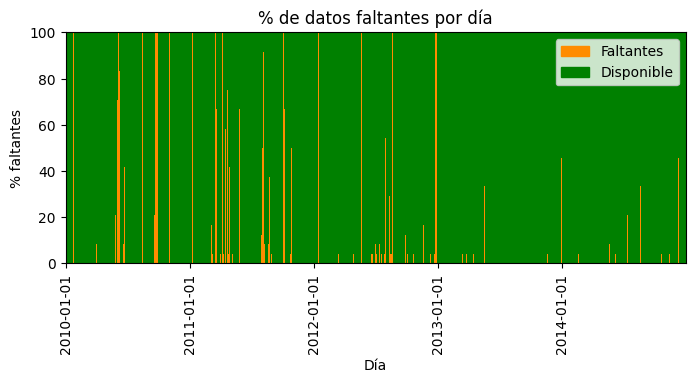

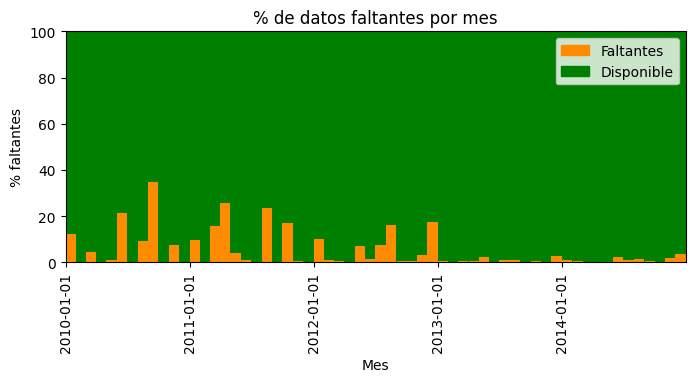

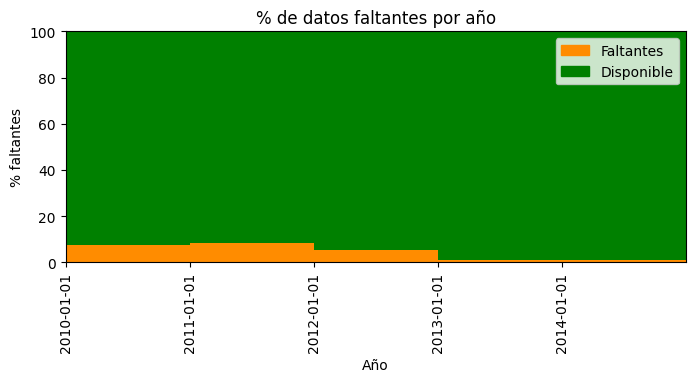

In [76]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as mpatches

missing_daily = df_new['pm2.5'].isnull().resample('D').mean() * 100
missing_monthly = df_new['pm2.5'].isnull().resample('MS').mean() * 100
missing_yearly = df_new['pm2.5'].isnull().resample('YS').mean() * 100
years = pd.date_range('2010-01-01', '2014-12-31', freq='YS')
faltantes_patch = mpatches.Patch(color='darkorange', label='Faltantes')
disponible_patch = mpatches.Patch(color='green', label='Disponible')


# Porcentaje de faltantes por día
plt.figure(figsize=(8, 3))
plt.bar(missing_daily.index, missing_daily.values, color='darkorange', width = 1, label='Faltantes', align='edge')
plt.title('% de datos faltantes por día')
plt.ylim(0,100)
plt.xlim(pd.Timestamp('2010-01-01'), pd.Timestamp('2014-12-31'))
plt.xticks(years, [y.strftime('%Y-%m-%d') for y in years], rotation=90)
plt.ylabel('% faltantes')
plt.xlabel('Día')
plt.gca().set_facecolor('green')
plt.legend(handles=[faltantes_patch, disponible_patch], loc='upper right')
plt.show()

# Porcentaje de faltantes por mes
plt.figure(figsize=(8, 3))
plt.bar(missing_monthly.index, missing_monthly.values, color='darkorange', width = 30, label='Faltantes', align='edge')
plt.ylim(0,100)
plt.xlim(pd.Timestamp('2010-01-01'), pd.Timestamp('2014-12-31'))
plt.xticks(years, [y.strftime('%Y-%m-%d') for y in years], rotation=90)
plt.title('% de datos faltantes por mes')
plt.ylabel('% faltantes')
plt.xlabel('Mes')
plt.gca().set_facecolor('green')
plt.legend(handles=[faltantes_patch, disponible_patch], loc='upper right')
plt.show()

# Porcentaje de faltantes por año
plt.figure(figsize=(8, 3))
plt.bar(missing_yearly.index, missing_yearly.values, color='darkorange', width = 366, label='Faltantes', align='edge')
plt.ylim(0,100)
plt.xlim(pd.Timestamp('2010-01-01'), pd.Timestamp('2014-12-31'))
plt.xticks(years, [y.strftime('%Y-%m-%d') for y in years], rotation=90)
plt.title('% de datos faltantes por año')
plt.ylabel('% faltantes')
plt.xlabel('Año')
plt.gca().set_facecolor('green')
plt.legend(handles=[faltantes_patch, disponible_patch], loc='upper right')
plt.show()

Porcentaje de datos faltantes consecutivos

Conteo de secuencias de datos erróneos consecutivos:
1 consecutivos -  0d 1h - 112 veces
2 consecutivos -  0d 2h - 29 veces
3 consecutivos -  0d 3h - 2 veces
4 consecutivos -  0d 4h - 5 veces
5 consecutivos -  0d 5h - 6 veces
6 consecutivos -  0d 6h - 4 veces
7 consecutivos -  0d 7h - 6 veces
8 consecutivos -  0d 8h - 3 veces
9 consecutivos -  0d 9h - 6 veces
10 consecutivos -  0d 10h - 3 veces
11 consecutivos -  0d 11h - 1 veces
12 consecutivos -  0d 12h - 2 veces
14 consecutivos -  0d 14h - 2 veces
16 consecutivos -  0d 16h - 2 veces
17 consecutivos -  0d 17h - 2 veces
19 consecutivos -  0d 19h - 2 veces
20 consecutivos -  0d 20h - 1 veces
22 consecutivos -  0d 22h - 2 veces
23 consecutivos -  0d 23h - 1 veces
24 consecutivos -  1d 0h - 3 veces
29 consecutivos -  1d 5h - 2 veces
37 consecutivos -  1d 13h - 1 veces
40 consecutivos -  1d 16h - 1 veces
42 consecutivos -  1d 18h - 1 veces
44 consecutivos -  1d 20h - 1 veces
48 consecutivos -  2d 0h - 1 veces
52 consecutivos -  2d 4h - 1 

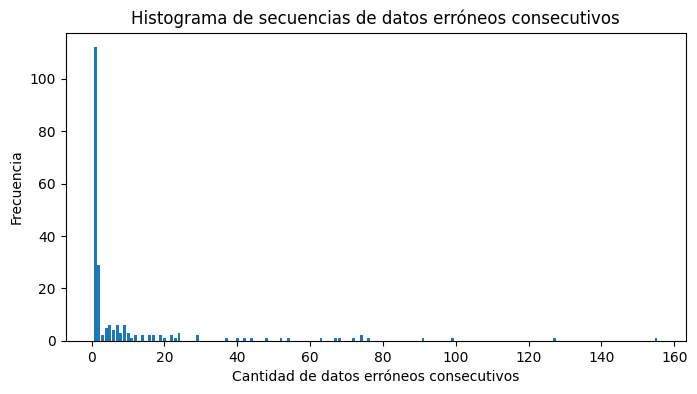

In [77]:
import numpy as np
import matplotlib.pyplot as plt

# Suponiendo que los datos erróneos son NaN
is_nan = df_new['pm2.5'].isna().astype(int)

# Encontrar las longitudes de las secuencias de datos erróneos consecutivos
bad_lengths = []
count = 0
for val in is_nan:
    if val == 1:
        count += 1
    elif count > 0:
        bad_lengths.append(count)
        count = 0
if count > 0:
    bad_lengths.append(count)

# Contar cuántas secuencias hay de cada longitud
from collections import Counter
length_counts = Counter(bad_lengths)



# Mostrar el conteo
print("Conteo de secuencias de datos erróneos consecutivos:")
for length, cnt in sorted(length_counts.items()):
    td = pd.Timedelta(hours=length)
    print(f"{length} consecutivos -  {td.days}d {td.seconds // 3600}h - {cnt} veces")

# Graficar histograma
plt.figure(figsize=(8,4))
plt.bar(length_counts.keys(), length_counts.values())
plt.xlabel('Cantidad de datos erróneos consecutivos')
plt.ylabel('Frecuencia')
plt.title('Histograma de secuencias de datos erróneos consecutivos')
plt.show()

## Preguntas sobre el análisis que se deben resolver:

1. Es posible utilizar modelos como XGBOOST que maneja faltantes sin hacer un tratamiento antes.
2. Con los datos tal cual, es posible mediante una interpolación simpre manejar los faltantes?, la variable pm2.5 puede cambiar facilmente de una hora a otra, de un dia a otro, o su variabilidad es alta?
3. Simplemente eliminar los nulos y trabajar con el dataset que queda es una opción?
4. Podríamos completar faltantes utilizando un primer modelo sencillo, tipo autoregresivo, o el mismo XGBOOST, y para los modelos que no manejen faltantes trabajar con la serie completa?

 .


<br><br><br><br><br><br><br><br><br><br><br><br><br>














 .

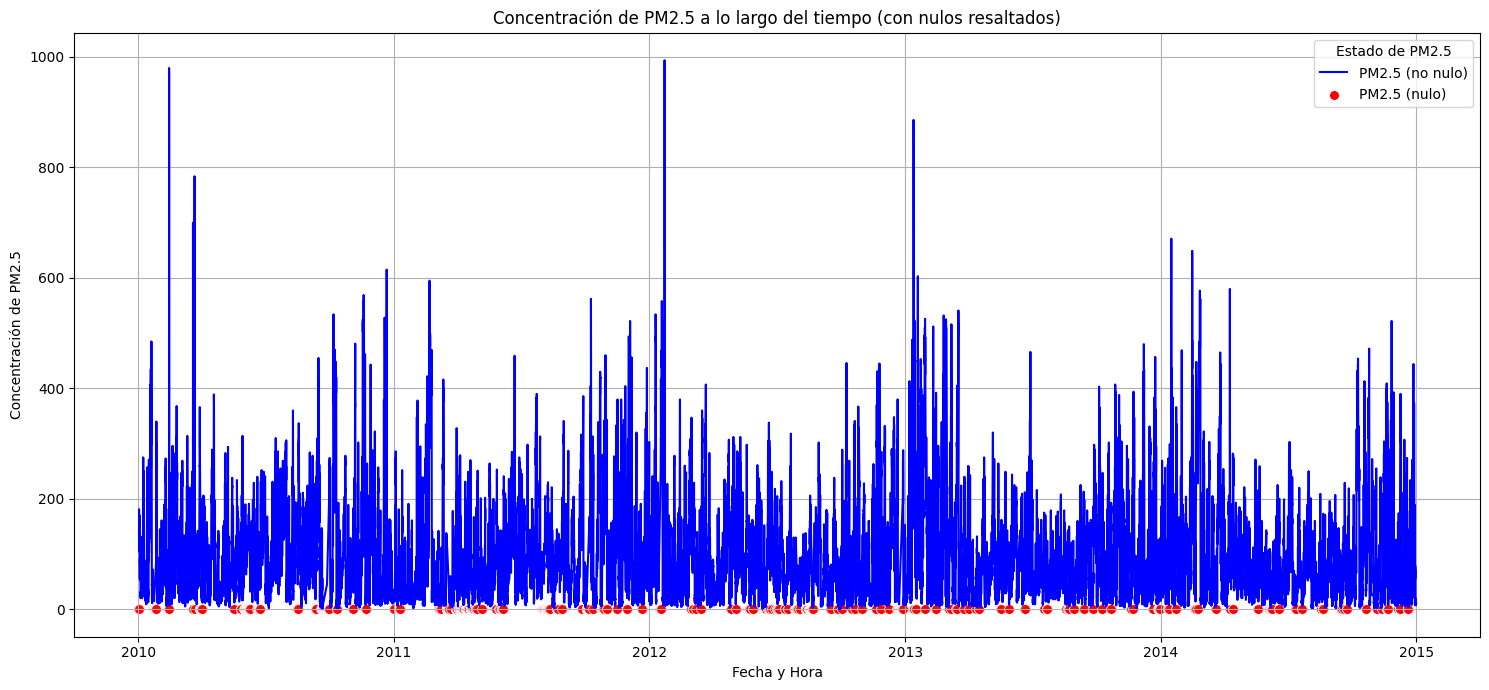

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear un gráfico de dispersión de pm2.5 a lo largo del tiempo
plt.figure(figsize=(15, 7))

# Filtrar los valores no nulos para el lineplot
df_non_null = df_new.dropna(subset=['pm2.5'])
sns.lineplot(x=df_non_null.index, y='pm2.5', data=df_non_null, color='blue', label='PM2.5 (no nulo)')

# Filtrar los valores nulos para el scatterplot
null_pm25 = df_new[df_new['pm2.5'].isna()].copy()

# Asignar un valor Y fijo para los nulos para que sean visibles
y_for_nulls = df_non_null['pm2.5'].min() if not df_non_null.empty else 0
null_pm25['pm2.5_marker_y'] = y_for_nulls

sns.scatterplot(x=null_pm25.index, y='pm2.5_marker_y', data=null_pm25, color='red', marker='o', s=50, label='PM2.5 (nulo)')

plt.title('Concentración de PM2.5 a lo largo del tiempo (con nulos resaltados)')
plt.xlabel('Fecha y Hora')
plt.ylabel('Concentración de PM2.5')
plt.grid(True)
plt.legend(title='Estado de PM2.5')
plt.tight_layout()
plt.show()